In [23]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, auc, accuracy_score,  classification_report, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

In [24]:
# df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx'))
# df_sissiz_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx'))
# df_multiperm_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'))
# df_multiperm_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx'))
# df_aln_shuffle = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'))

In [25]:
df_sissi = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissi.xlsx"))
df_sissiz_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx"))
df_sissiz_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx"))
df_multiperm_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx"))
df_multiperm_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx"))
df_aln_shuffle = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/alifoldz.xlsx"))

## Confusion Matrix

In [46]:
def plot_confusion_matrix(cm, title, ax=None):
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')
    ax.xaxis.set_ticklabels(['False', 'True'])
    ax.yaxis.set_ticklabels(['False', 'True'])

## ROC-Curve

In [47]:
def plot_roc_curve(fper, tper, title, ax=None):
    roc_auc = auc(fper, tper)
    ax.plot(fper, tper, color='red', label=f'ROC curve (area = {roc_auc:0.2f})')
    ax.plot([0, 1], [0, 1], color='green', linestyle='--', label='No Skill')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend()

# Logistische Regressions Auswertung

In [48]:
def logistic_regression_pipeline(data, title, target_column='z-score calculated from 7. 8. and 9.', threshold=0, class_weights={0: 1, 1: 3}):

    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    

    # Standardisierung des z-scores
    data["z-score"] = (data[target_column] - data[target_column].mean()) / data[target_column].std()
    data["label"] = np.where(data["z-score"] > threshold, 1, 0)

    # Erstellen der 'label' Spalte mit dem Schwellenwert
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Logistische Regression trainieren
    log_reg = LogisticRegression(class_weight=class_weights, max_iter=1000, random_state=0)
    log_reg.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(log_reg, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = log_reg.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)
    print("False-Negative Rate: ", 1 - cm[1][0] / (cm[1][0] + cm[1][1]))

    # Schritt 5: ROC-Kurve und AUC berechnen
    y_test_prob = log_reg.predict_proba(X_test)[:, 1]
    fper, tper, thresholds = roc_curve(y_test, y_test_prob)
    auc_score = roc_auc_score(y_test, y_test_prob)
    print(f"AUC score: {auc_score}")
   
    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, title, ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, title, ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()  # Optional: Verbessert das Layout
    plt.show()

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    38762
0    31238
Name: count, dtype: int64
y_test label
1    16849
0    13151
Name: count, dtype: int64
Cross-validation scores: [0.994      0.99471429 0.99542857 0.99557143 0.995      0.99442857
 0.995      0.99657143 0.99542857 0.99642857]
Mean CV score: 0.9952571428571428
Accuracy score:  0.9947333333333334
False-Negative Rate:  1.0
AUC score: 0.9999949138284064


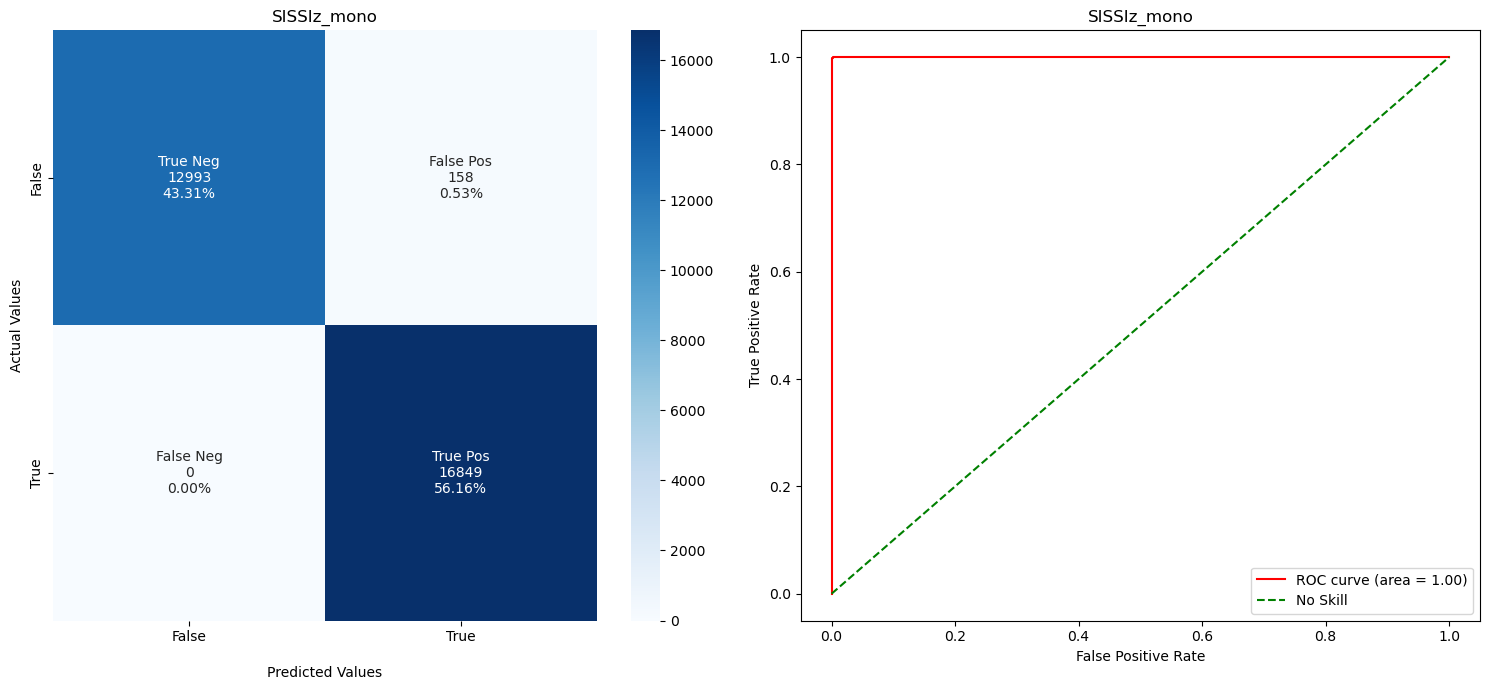

In [49]:
logistic_regression_pipeline(df_sissiz_mono, "SISSIz_mono")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    38125
0    31875
Name: count, dtype: int64
y_test label
1    16412
0    13588
Name: count, dtype: int64
Cross-validation scores: [0.99471429 0.99785714 0.995      0.99585714 0.99528571 0.99414286
 0.99442857 0.99585714 0.99557143 0.99485714]
Mean CV score: 0.9953571428571427
Accuracy score:  0.9949333333333333
False-Negative Rate:  1.0
AUC score: 0.9999980583504349


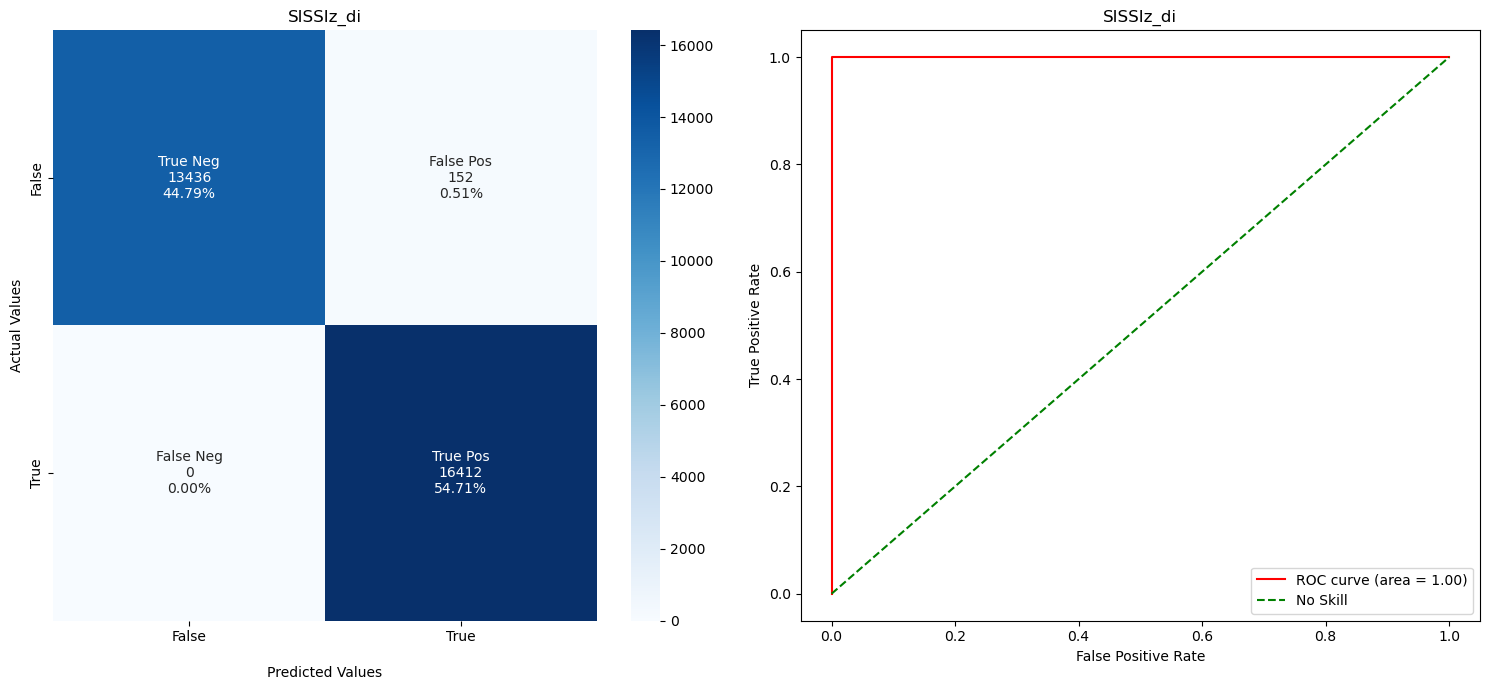

In [50]:
logistic_regression_pipeline(df_sissiz_di, "SISSIz_di")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    37092
0    32908
Name: count, dtype: int64
y_test label
1    15821
0    14179
Name: count, dtype: int64
Cross-validation scores: [0.99357143 0.994      0.99285714 0.99271429 0.99128571 0.99242857
 0.99328571 0.99357143 0.992      0.99114286]
Mean CV score: 0.9926857142857145
Accuracy score:  0.9923333333333333
False-Negative Rate:  1.0
AUC score: 0.999993781370617


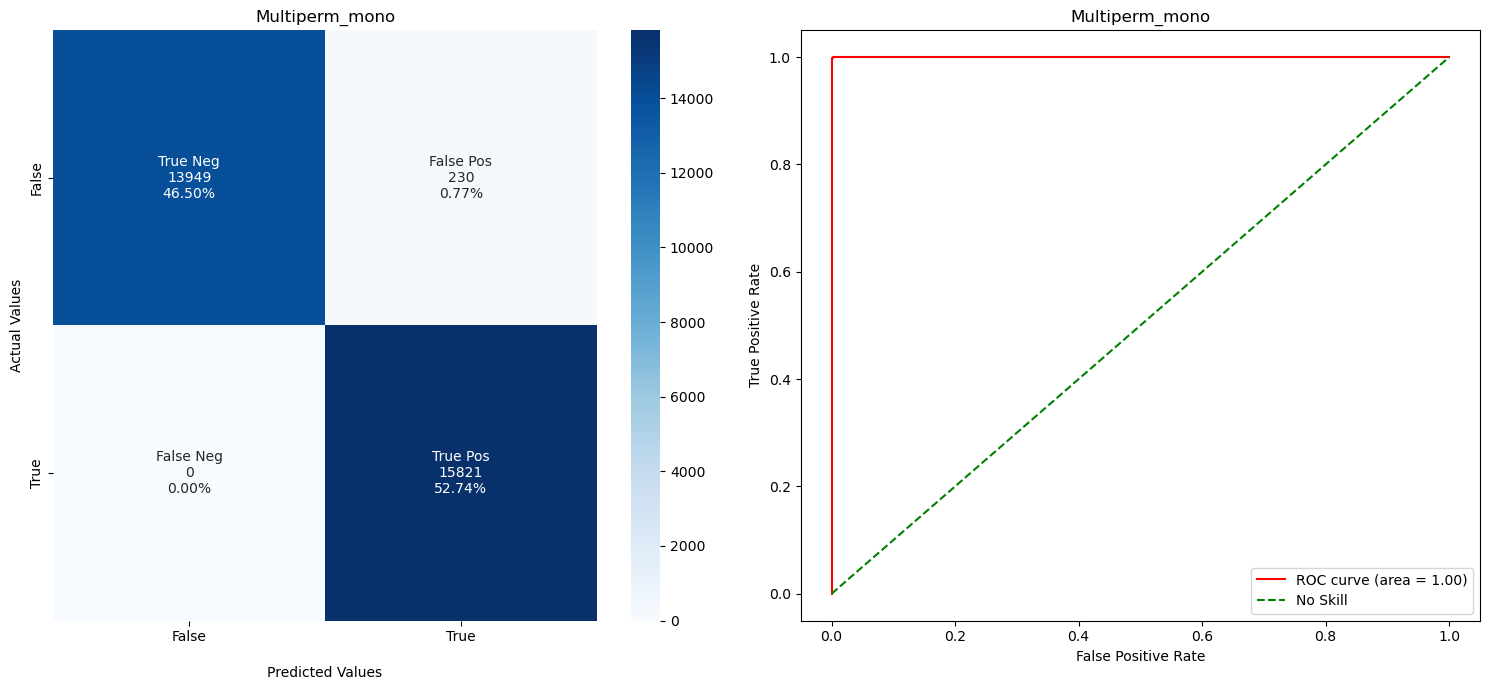

In [51]:
logistic_regression_pipeline(df_multiperm_mono, "Multiperm_mono")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    36974
0    33026
Name: count, dtype: int64
y_test label
1    15798
0    14202
Name: count, dtype: int64
Cross-validation scores: [0.99285714 0.99242857 0.99285714 0.995      0.99271429 0.99314286
 0.99257143 0.994      0.99128571 0.99157143]
Mean CV score: 0.9928428571428572
Accuracy score:  0.9928666666666667
False-Negative Rate:  1.0
AUC score: 0.9999927795644344


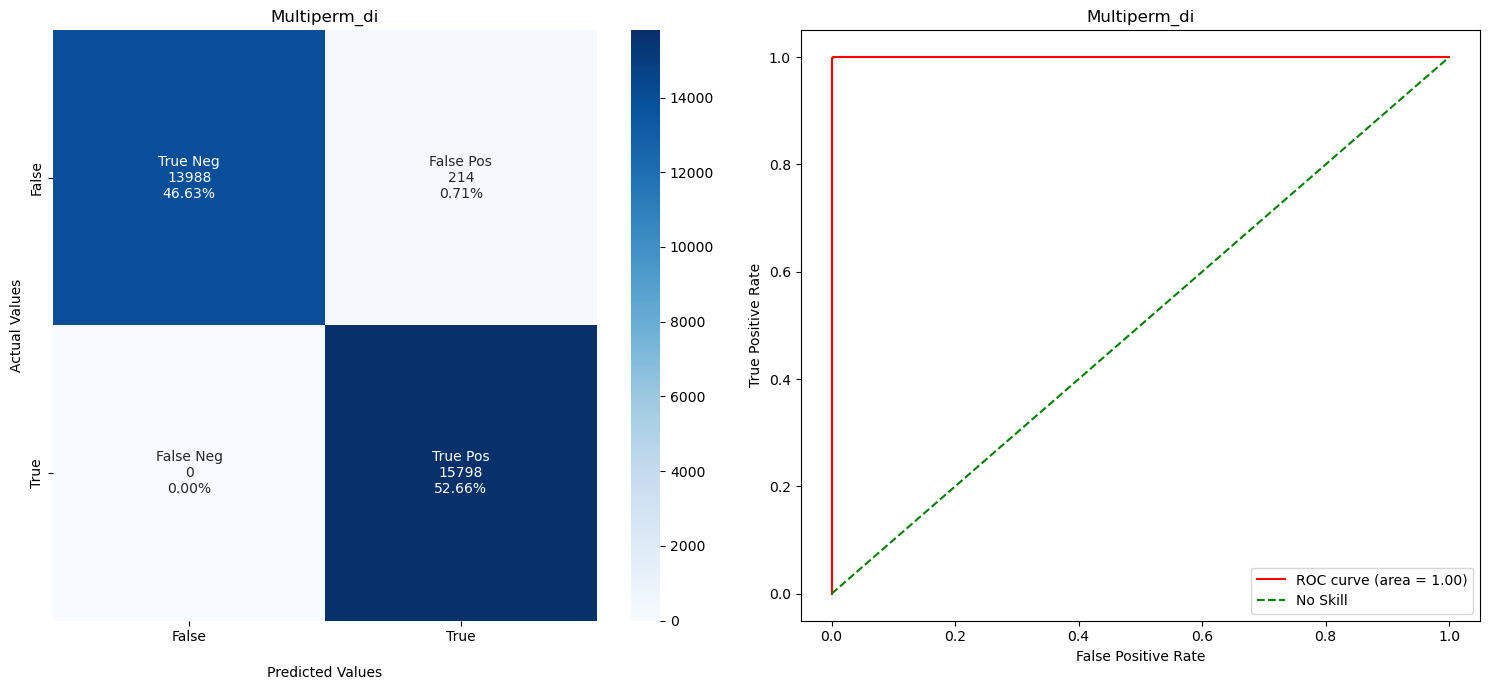

In [52]:
logistic_regression_pipeline(df_multiperm_di, "Multiperm_di")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    36991
0    33009
Name: count, dtype: int64
y_test label
1    15865
0    14135
Name: count, dtype: int64
Cross-validation scores: [0.99285714 0.99028571 0.993      0.993      0.99085714 0.99357143
 0.99142857 0.99142857 0.99157143 0.99057143]
Mean CV score: 0.9918571428571429
Accuracy score:  0.9924
False-Negative Rate:  1.0
AUC score: 0.9999957012603357


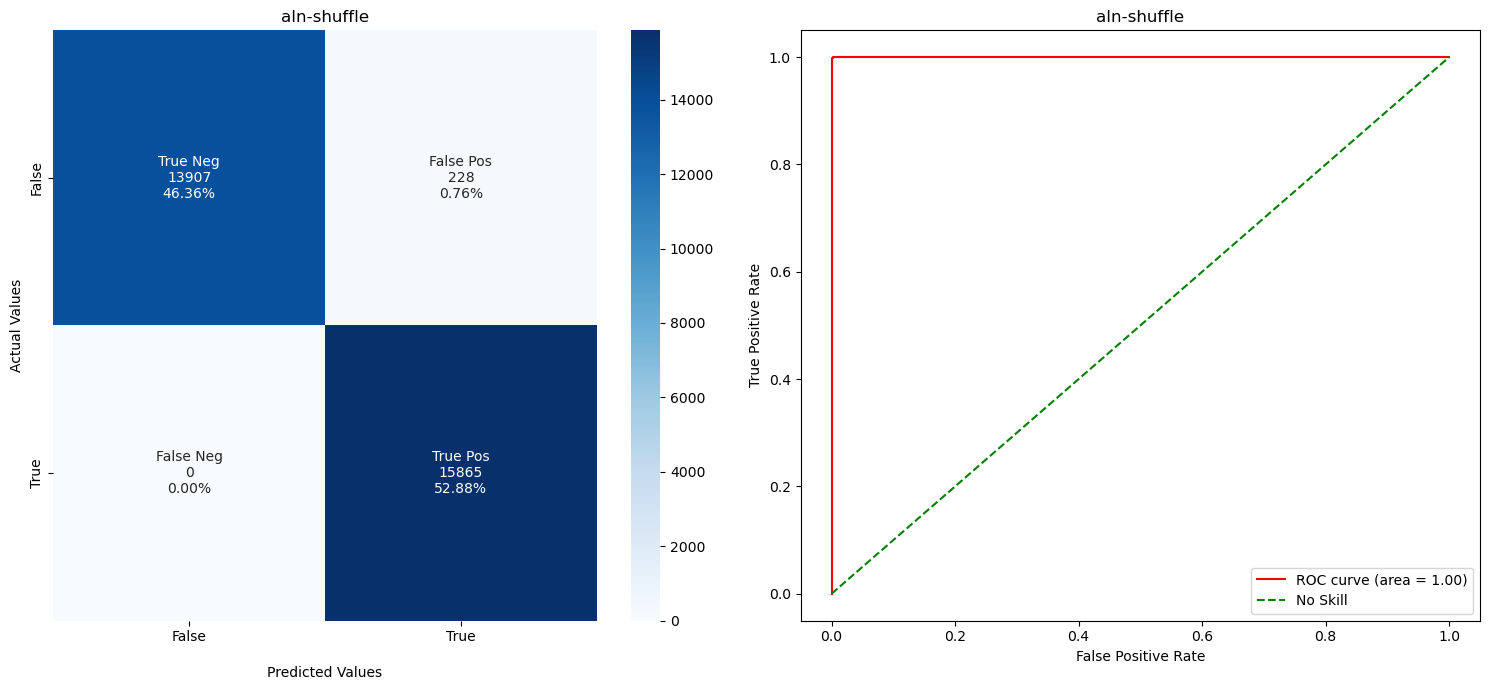

In [53]:
logistic_regression_pipeline(df_aln_shuffle, "aln-shuffle")

# Random Forest

In [54]:
def random_forest_pipeline(data, title, target_column='z-score calculated from 7. 8. and 9.', threshold=0, class_weights={0: 1, 1: 3}):
    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    
    # Standardisierung des z-scores
    data["z-score"] = (data[target_column] - data[target_column].mean()) / data[target_column].std()
    data["label"] = np.where(data["z-score"] > threshold, 1, 0)

    # Erstellen der 'label' Spalte mit dem Schwellenwert
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Random Forest trainieren
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight=class_weights, random_state=0)
    rf_model.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(rf_model, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = rf_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)

    if cm.shape == (2,2):  # Prüfe, ob die Confusion Matrix 2x2 ist
        false_negative_rate = 1 - cm[1][0] / (cm[1][0] + cm[1][1])
        print("False-Negative Rate: ", false_negative_rate)
    else:
        print("Warnung: Nur eine Klasse in y_test vorhanden, False-Negative Rate nicht berechenbar.")


    # Schritt 5: ROC-Kurve und AUC berechnen
    global y_test_prob
    y_test_prob = rf_model.predict_proba(X_test)[:, 1]
    fper, tper, _ = roc_curve(y_test, y_test_prob)

    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, title, ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, title, ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()
    plt.show()

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    38762
0    31238
Name: count, dtype: int64
y_test label
1    16849
0    13151
Name: count, dtype: int64
Cross-validation scores: [0.90414286 0.91314286 0.89857143 0.90814286 0.906      0.90271429
 0.90485714 0.90342857 0.90471429 0.90514286]
Mean CV score: 0.9050857142857144
Accuracy score:  0.9019
False-Negative Rate:  0.9917502522404891


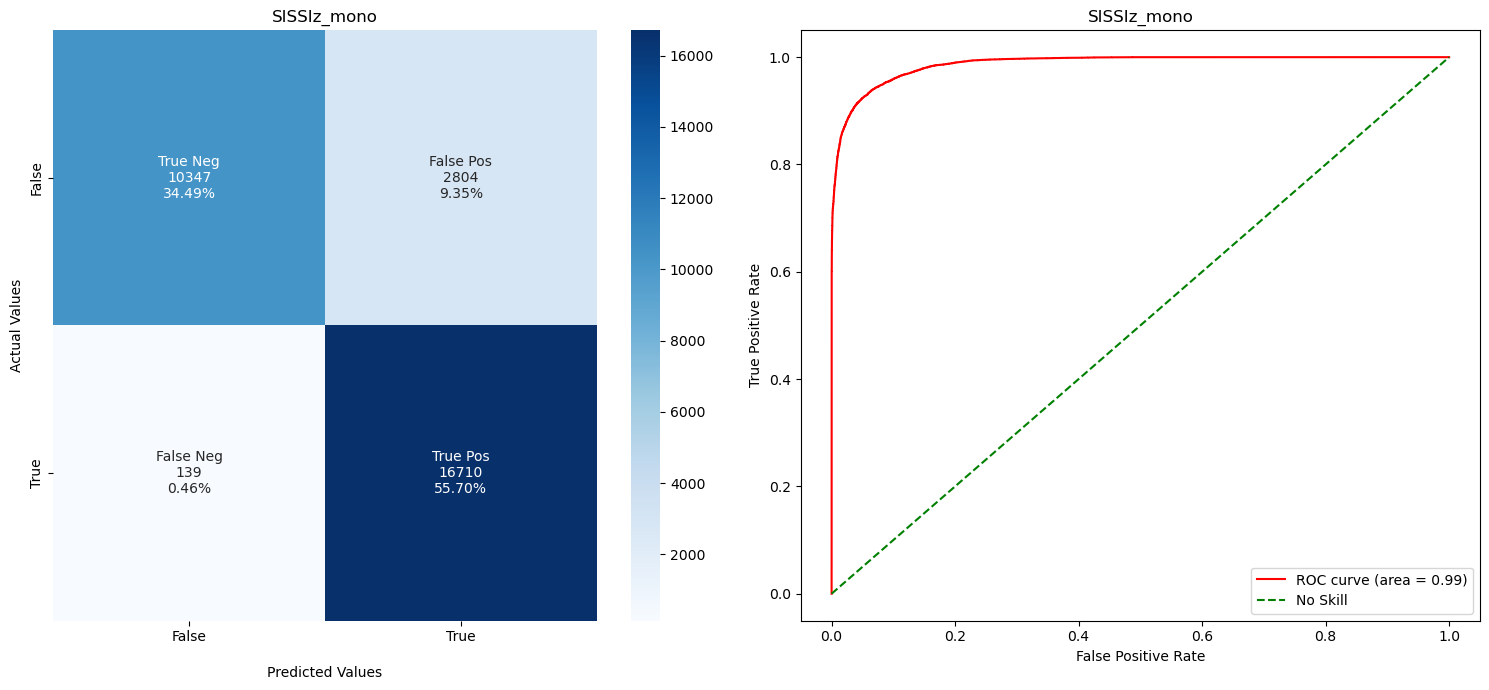

In [55]:
random_forest_pipeline(df_sissiz_mono, "SISSIz_mono")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    38125
0    31875
Name: count, dtype: int64
y_test label
1    16412
0    13588
Name: count, dtype: int64
Cross-validation scores: [0.89928571 0.89614286 0.90014286 0.9        0.90228571 0.89757143
 0.89642857 0.89985714 0.90357143 0.89871429]
Mean CV score: 0.8994
Accuracy score:  0.8969
False-Negative Rate:  0.9889105532537168


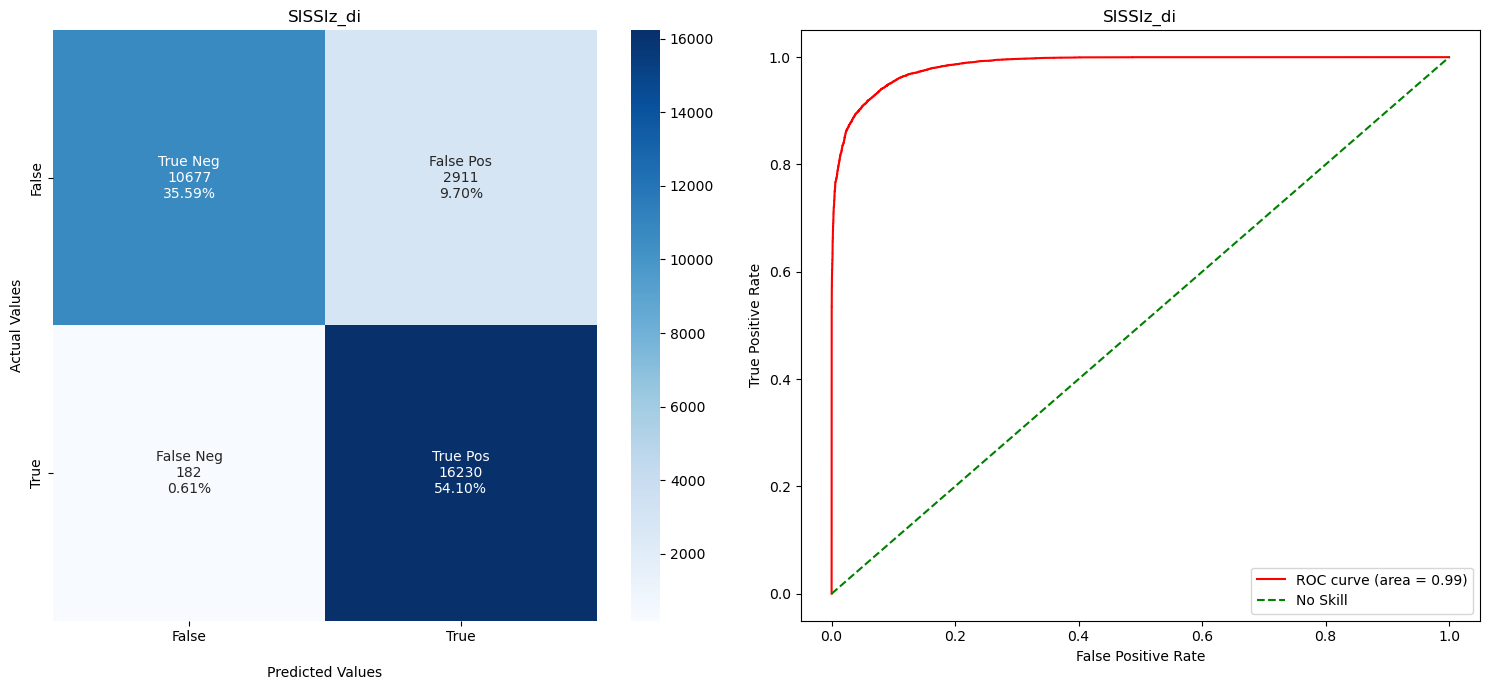

In [56]:
random_forest_pipeline(df_sissiz_di, "SISSIz_di")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    37092
0    32908
Name: count, dtype: int64
y_test label
1    15821
0    14179
Name: count, dtype: int64
Cross-validation scores: [0.88671429 0.88842857 0.89442857 0.89142857 0.88985714 0.88414286
 0.88828571 0.89314286 0.88414286 0.88728571]
Mean CV score: 0.8887857142857142
Accuracy score:  0.8892666666666666
False-Negative Rate:  0.9922255230389988


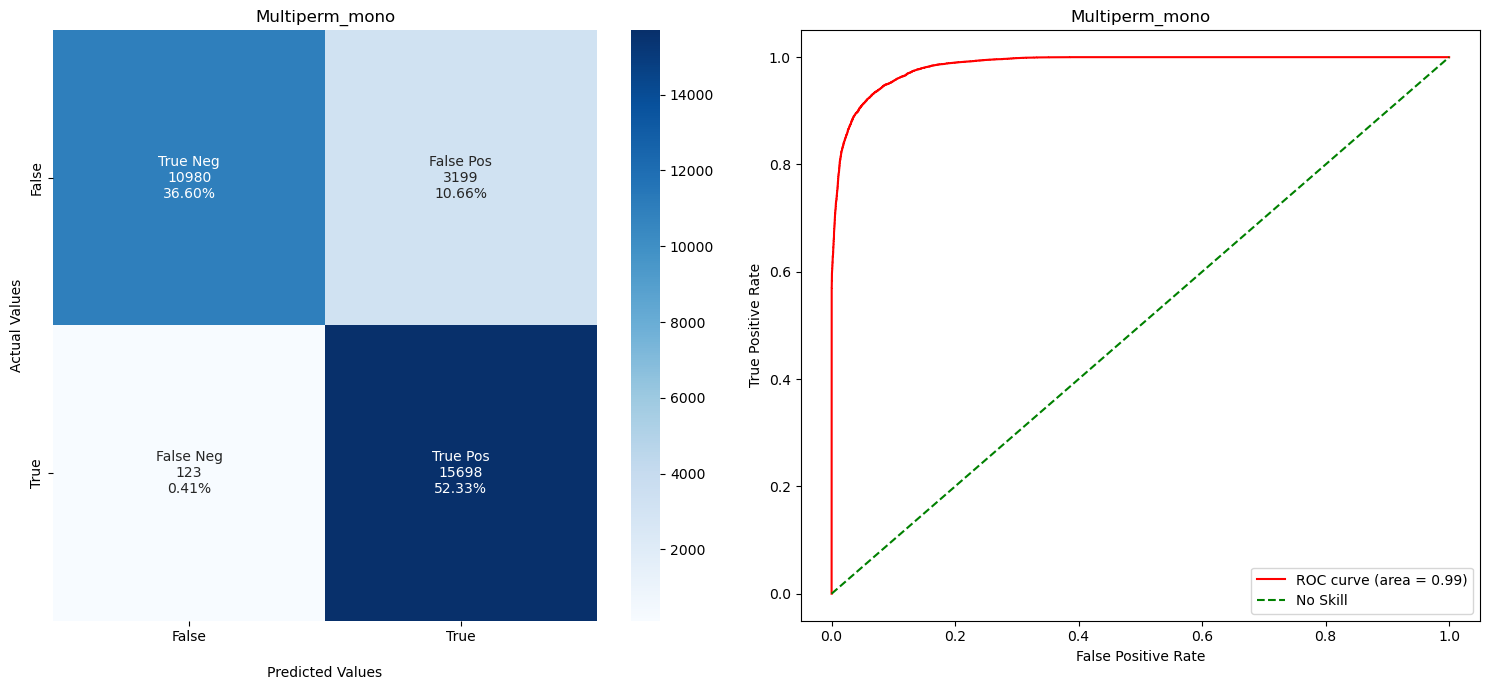

In [57]:
random_forest_pipeline(df_multiperm_mono, "Multiperm_mono")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    36974
0    33026
Name: count, dtype: int64
y_test label
1    15798
0    14202
Name: count, dtype: int64
Cross-validation scores: [0.88957143 0.88385714 0.89385714 0.88828571 0.887      0.88985714
 0.88814286 0.87714286 0.887      0.885     ]
Mean CV score: 0.8869714285714286
Accuracy score:  0.8830666666666667
False-Negative Rate:  0.9931636916065325


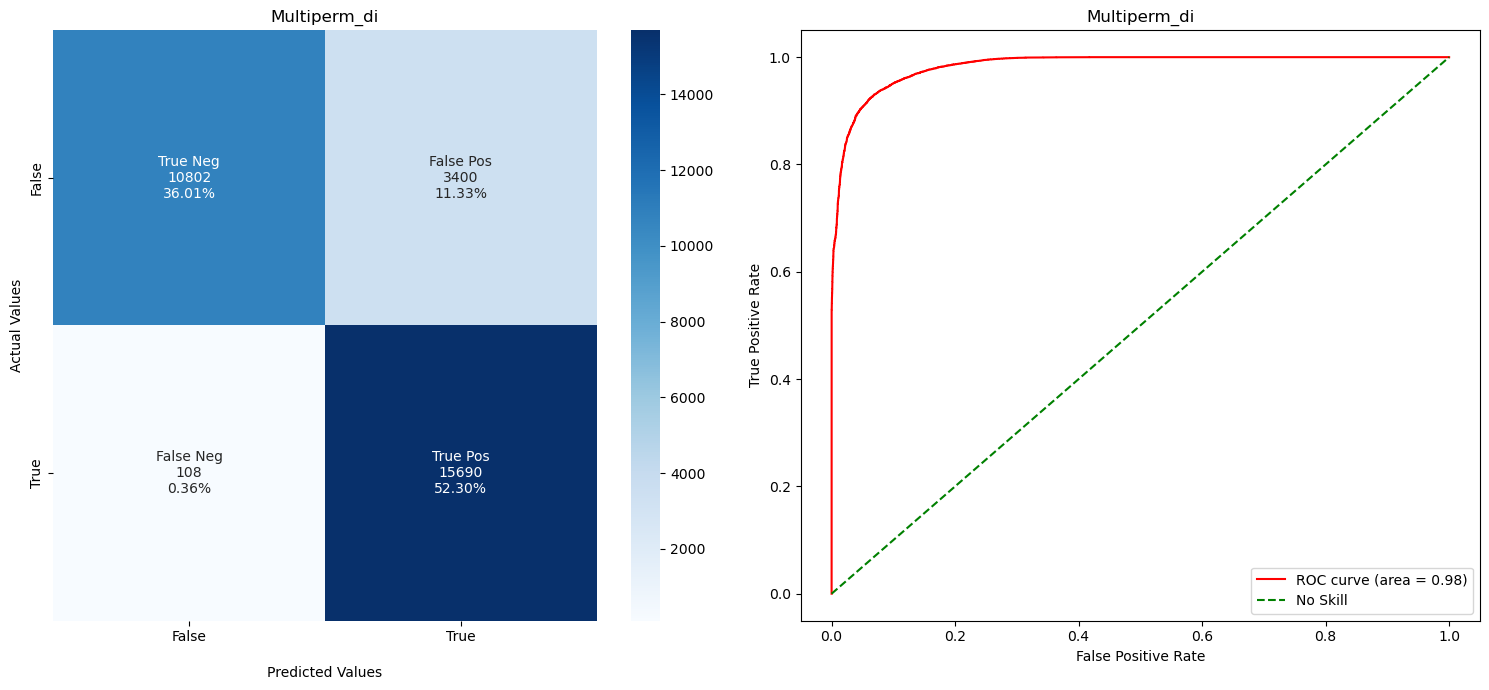

In [58]:
random_forest_pipeline(df_multiperm_di, "Multiperm_di")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    36991
0    33009
Name: count, dtype: int64
y_test label
1    15865
0    14135
Name: count, dtype: int64
Cross-validation scores: [0.90757143 0.90414286 0.90842857 0.90614286 0.90542857 0.90871429
 0.90342857 0.899      0.90357143 0.90271429]
Mean CV score: 0.9049142857142858
Accuracy score:  0.9038666666666667
False-Negative Rate:  0.9953986763315474


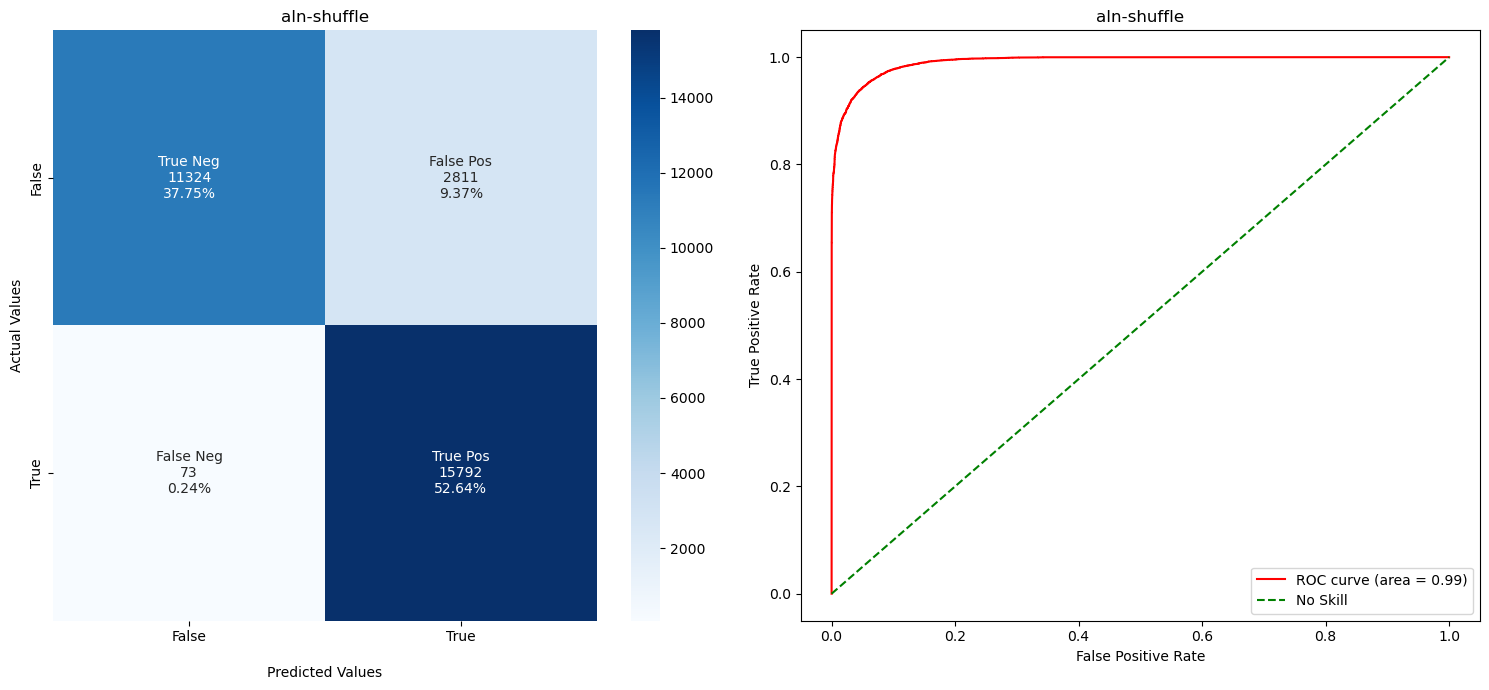

In [59]:
random_forest_pipeline(df_aln_shuffle, "aln-shuffle")

## XGBOOST

In [60]:
def gradient_boosting_pipeline(data, title, target_column='z-score calculated from 7. 8. and 9.', threshold=0, class_weights={0: 1, 1: 3}):
    # Schritt 1: Features und Zielvariable aufteilen
    X = data[['Mean Pairwise Identity (MPI) of the input alignment',
              'Average MPI of the sampled alignments.',
              'Standard deviation of the MPIs of the sampled alignments',
              'Structural Conservation Index (SCI)',
              'GC-Content',
              'RNAalifold consensus Minimum Free Energy (MFE) of the original alignment.',
              'Average consensus MFE in the sampled alignments',
              'Standard deviation of the consensus MFE in the sampled alignments']]
    
    # Standardisierung des z-scores
    data["z-score"] = (data[target_column] - data[target_column].mean()) / data[target_column].std()
    data["label"] = np.where(data["z-score"] > threshold, 1, 0)
    y = data["label"]

    # Splitte in Training- und Testdaten
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
    
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print('y_train', y_train.value_counts())
    print('y_test', y_test.value_counts())

    # Schritt 2: Gradient Boosting (XGBoost) trainieren
    gb_model = XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=class_weights[1], random_state=0)
    gb_model.fit(X_train, y_train)

    # Schritt 3: Modellbewertung mit Cross-Validation
    scores = cross_val_score(gb_model, X_train, y_train, cv=10)
    print(f"Cross-validation scores: {scores}")
    print(f"Mean CV score: {scores.mean()}")

    # Schritt 4: Vorhersagen und Modell testen
    y_pred = gb_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Berechnung der Accuracy und False Negative Rate
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy score: ", acc)

    if cm.shape == (2,2):  # Prüfe, ob die Confusion Matrix 2x2 ist
        false_negative_rate = 1 - cm[1][0] / (cm[1][0] + cm[1][1])
        print("False-Negative Rate: ", false_negative_rate)
    else:
        print("Warnung: Nur eine Klasse in y_test vorhanden, False-Negative Rate nicht berechenbar.")

    # Schritt 5: ROC-Kurve und AUC berechnen
    global y_test_prob
    y_test_prob = gb_model.predict_proba(X_test)[:, 1]
    fper, tper, _ = roc_curve(y_test, y_test_prob)

    # Erstelle Subplots für beide Plots
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))  # 1 Zeile, 2 Spalten
    
    # Plot Confusion Matrix
    plot_confusion_matrix(cm, title, ax=ax[0])

    # Plot ROC Curve
    plot_roc_curve(fper, tper, title, ax=ax[1])

    # Zeige die Plots an
    plt.tight_layout()
    plt.show()

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    38762
0    31238
Name: count, dtype: int64
y_test label
1    16849
0    13151
Name: count, dtype: int64
Cross-validation scores: [0.99171429 0.99071429 0.992      0.98914286 0.99128571 0.99142857
 0.99171429 0.99228571 0.99242857 0.992     ]
Mean CV score: 0.9914714285714286
Accuracy score:  0.991
False-Negative Rate:  0.9965576592082617


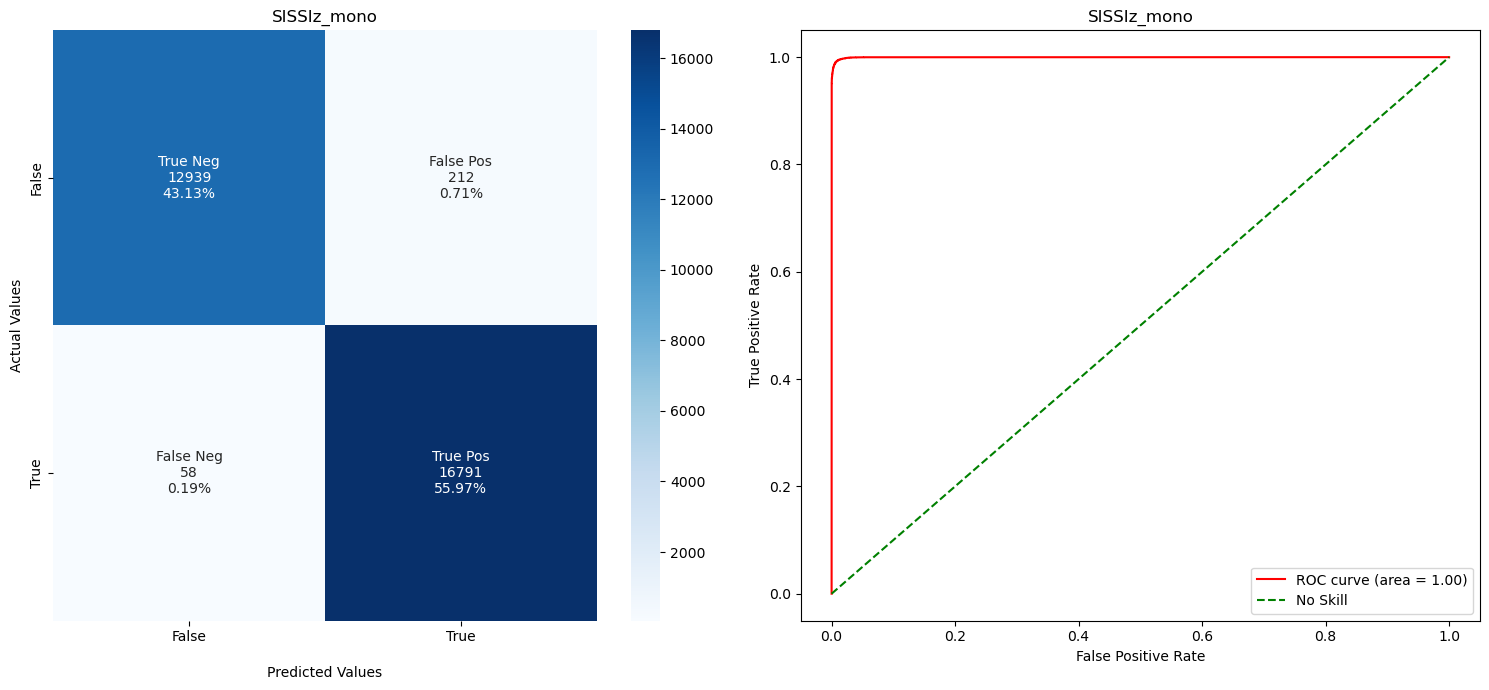

In [61]:
gradient_boosting_pipeline(df_sissiz_mono, "SISSIz_mono")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    38125
0    31875
Name: count, dtype: int64
y_test label
1    16412
0    13588
Name: count, dtype: int64
Cross-validation scores: [0.99028571 0.994      0.99328571 0.99071429 0.99       0.98942857
 0.99       0.99028571 0.99157143 0.992     ]
Mean CV score: 0.9911571428571431
Accuracy score:  0.9903
False-Negative Rate:  0.996953448696076


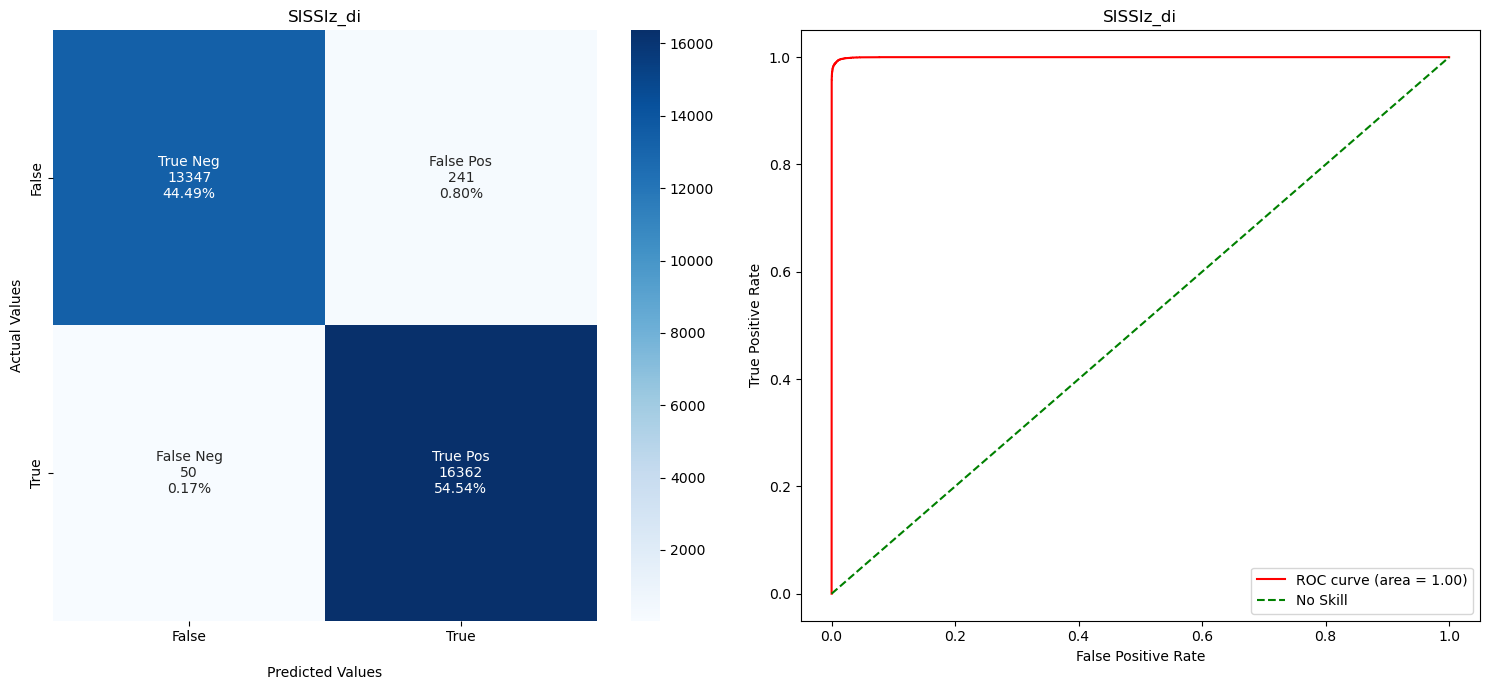

In [62]:
gradient_boosting_pipeline(df_sissiz_di, "SISSIz_di")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    37092
0    32908
Name: count, dtype: int64
y_test label
1    15821
0    14179
Name: count, dtype: int64
Cross-validation scores: [0.99257143 0.99228571 0.99128571 0.98928571 0.99128571 0.99157143
 0.99242857 0.99185714 0.99142857 0.989     ]
Mean CV score: 0.9913000000000001
Accuracy score:  0.9911333333333333
False-Negative Rate:  0.9979141647177802


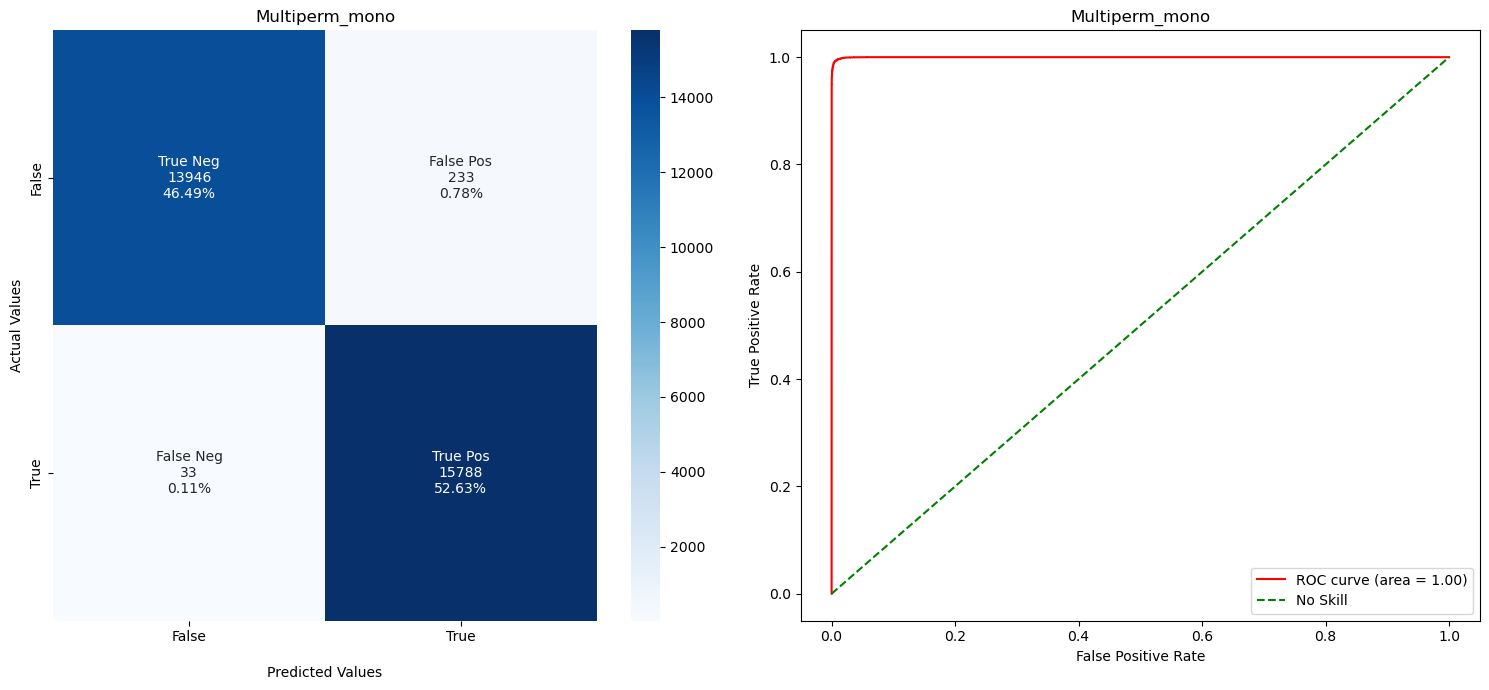

In [63]:
gradient_boosting_pipeline(df_multiperm_mono, "Multiperm_mono")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    36974
0    33026
Name: count, dtype: int64
y_test label
1    15798
0    14202
Name: count, dtype: int64
Cross-validation scores: [0.99157143 0.99071429 0.99071429 0.992      0.99114286 0.991
 0.99314286 0.99128571 0.98928571 0.988     ]
Mean CV score: 0.9908857142857143
Accuracy score:  0.9906
False-Negative Rate:  0.9970882390175971


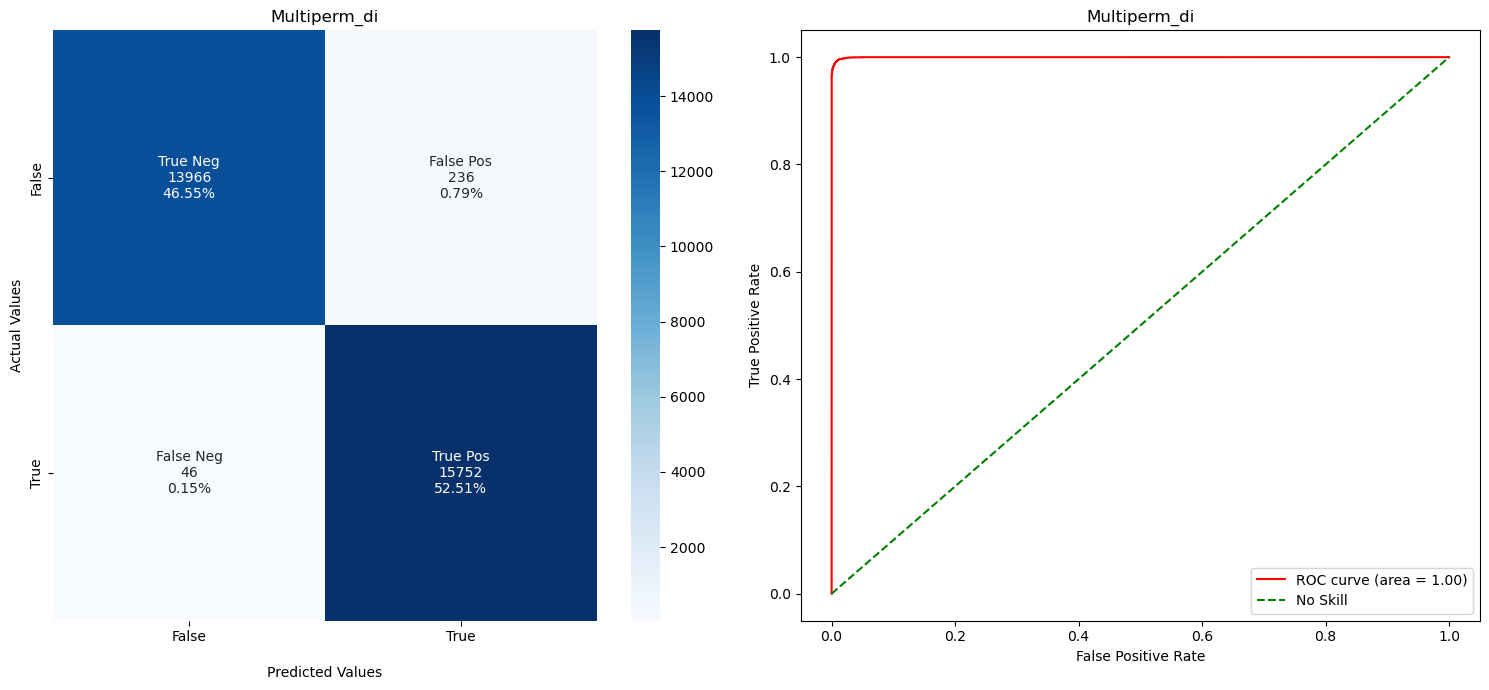

In [64]:
gradient_boosting_pipeline(df_multiperm_di, "Multiperm_di")

X_train: (70000, 8)
y_train: (70000,)
X_test: (30000, 8)
y_test: (30000,)
y_train label
1    36991
0    33009
Name: count, dtype: int64
y_test label
1    15865
0    14135
Name: count, dtype: int64
Cross-validation scores: [0.99357143 0.99128571 0.993      0.99257143 0.992      0.99042857
 0.991      0.993      0.99285714 0.99257143]
Mean CV score: 0.9922285714285716
Accuracy score:  0.9931666666666666
False-Negative Rate:  0.9972265994327135


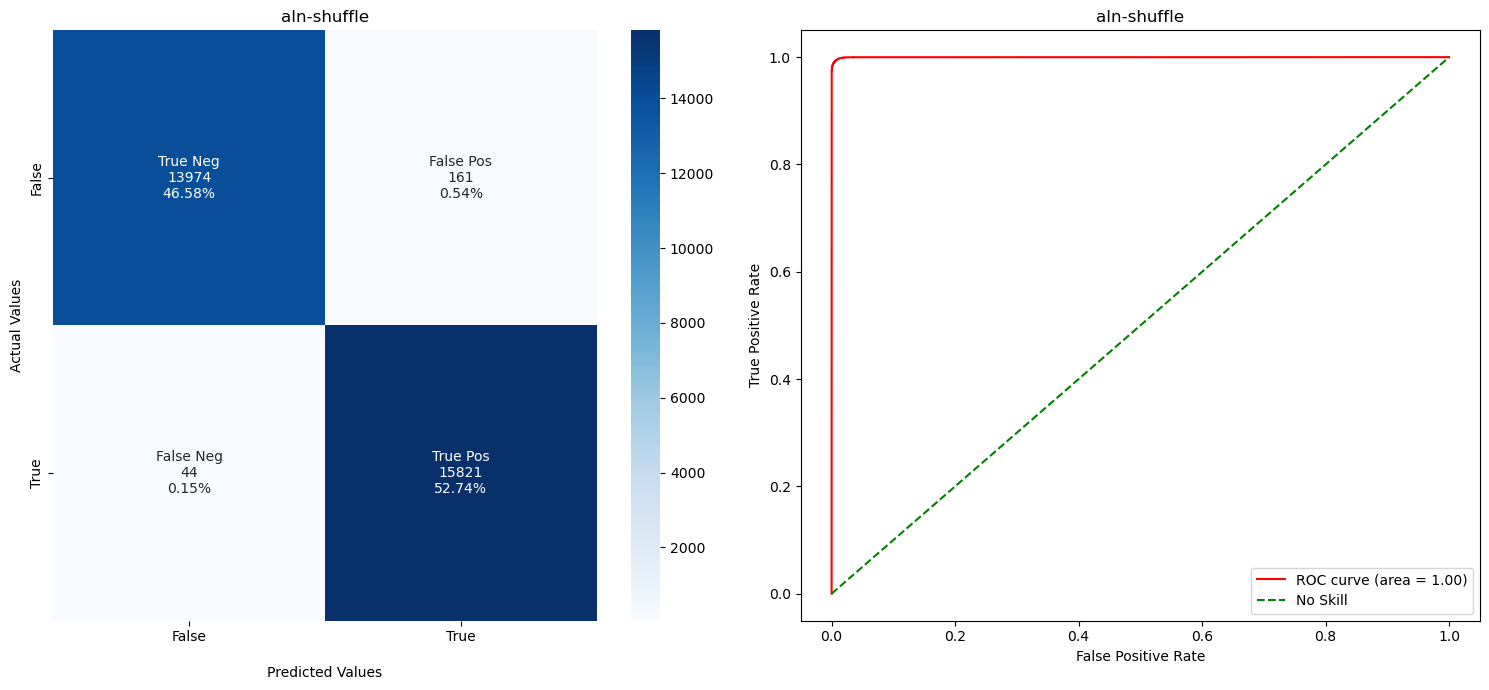

In [65]:
gradient_boosting_pipeline(df_aln_shuffle, "aln-shuffle")